In [68]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# DATA COLLECTION

In [28]:
df = pd.read_csv("neat_medical_dataset.csv")

In [29]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose Level,BMI,Symptoms,Medical History,Blood Test Results,Disease
0,63,Male,145,233,High,24.7,Dizziness,No Major History,Fixed Defect,Yes
1,37,Male,130,250,Normal,34.2,Fatigue,No Major History,Reversible Defect,Yes
2,41,Female,130,204,Normal,30.6,Shortness of Breath,No Major History,Reversible Defect,Yes
3,56,Male,120,236,Normal,28.4,Shortness of Breath,No Major History,Reversible Defect,Yes
4,57,Female,120,354,Normal,21.1,Chest Pain,Cardiac History,Reversible Defect,Yes
...,...,...,...,...,...,...,...,...,...,...
1883,60,Male,140,207,Normal,31.1,Chest Pain,Cardiac History,Abnormal,No
1884,46,Male,140,311,Normal,21.1,Chest Pain,Cardiac History,Abnormal,No
1885,59,Male,134,204,Normal,26.1,Dizziness,No Major History,Reversible Defect,No
1886,54,Male,154,232,Normal,18.7,Shortness of Breath,No Major History,Reversible Defect,No


In [30]:
print("First 5 Rows of Dataset")
print(df.head())


First 5 Rows of Dataset
   Age  Gender  Blood Pressure  Cholesterol Glucose Level   BMI  \
0   63    Male             145          233          High  24.7   
1   37    Male             130          250        Normal  34.2   
2   41  Female             130          204        Normal  30.6   
3   56    Male             120          236        Normal  28.4   
4   57  Female             120          354        Normal  21.1   

              Symptoms   Medical History Blood Test Results Disease  
0            Dizziness  No Major History       Fixed Defect     Yes  
1              Fatigue  No Major History  Reversible Defect     Yes  
2  Shortness of Breath  No Major History  Reversible Defect     Yes  
3  Shortness of Breath  No Major History  Reversible Defect     Yes  
4           Chest Pain   Cardiac History  Reversible Defect     Yes  


In [31]:
print("\nDataset Information")
print(df.info())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1888 non-null   int64  
 1   Gender              1888 non-null   object 
 2   Blood Pressure      1888 non-null   int64  
 3   Cholesterol         1888 non-null   int64  
 4   Glucose Level       1888 non-null   object 
 5   BMI                 1888 non-null   float64
 6   Symptoms            1888 non-null   object 
 7   Medical History     1888 non-null   object 
 8   Blood Test Results  1769 non-null   object 
 9   Disease             1888 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 147.6+ KB
None


In [32]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(1888, 10)


# EDA (Exploratory Data Analysis)

In [33]:
# HANDLE MISSING VALUES
print("\nMissing Values Before Handling")
print(df.isnull().sum())


Missing Values Before Handling
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol             0
Glucose Level           0
BMI                     0
Symptoms                0
Medical History         0
Blood Test Results    119
Disease                 0
dtype: int64


In [34]:
print("\nMissing Values After Handling")
print(df.isnull().sum())



Missing Values After Handling
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol             0
Glucose Level           0
BMI                     0
Symptoms                0
Medical History         0
Blood Test Results    119
Disease                 0
dtype: int64


In [35]:
print("\nDuplicate Rows Before Removal")
print(df.duplicated().sum())


Duplicate Rows Before Removal
20


In [36]:

# Remove Duplicate Rows
df = df.drop_duplicates()


In [37]:
print("\nDuplicate Rows After Removal")
print(df.duplicated().sum())


Duplicate Rows After Removal
0


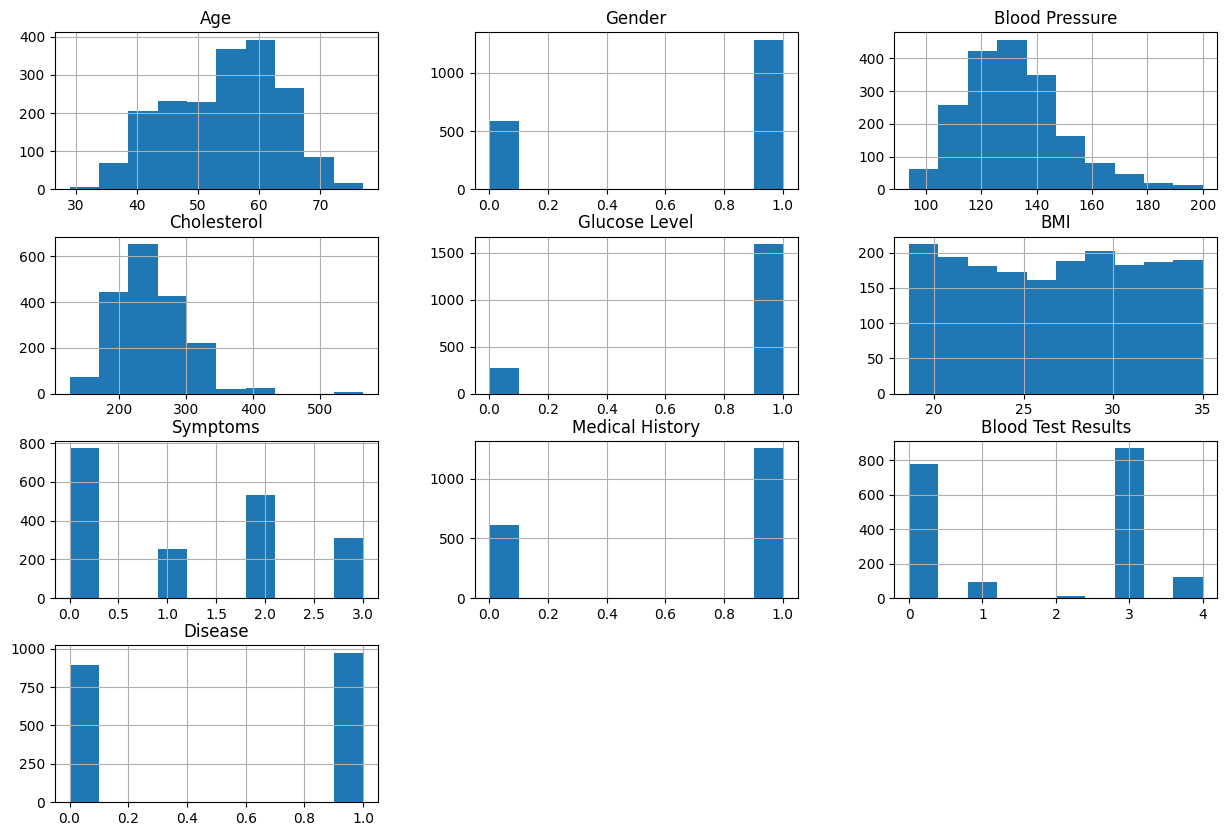

In [78]:
df.hist(figsize=(15,10))
plt.show()

In [39]:
print(df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose Level',
       'BMI', 'Symptoms', 'Medical History', 'Blood Test Results', 'Disease'],
      dtype='object')


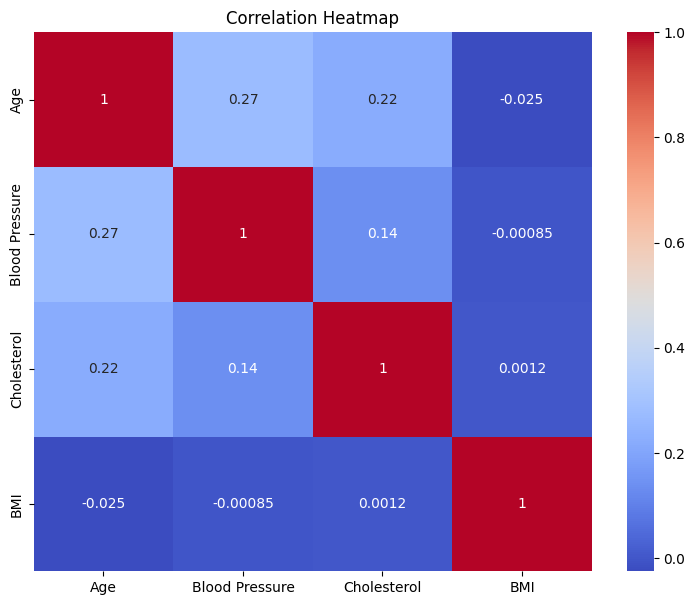

In [40]:
plt.figure(figsize=(9,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [86]:
# ==========================================
# EDA FUNCTION
# ==========================================
def plot_credit_numeric_eda_separate(df, save_dir="static"):

    os.makedirs(save_dir, exist_ok=True)

    # Select numeric columns
    num = df.select_dtypes(include=[np.number])

    # Histogram for Numeric Columns
    for col in num.columns:

        plt.figure(figsize=(9,5))

        plt.hist(num[col], bins=15)

        plt.title(f"{col} Distribution")

        plt.xlabel(col)

        plt.ylabel("Frequency")

        plt.tight_layout()

        plt.savefig(f"{save_dir}/{col}_hist.png")

        plt.show()

        plt.close()

    # ==========================================
    # TOP 10 VALUES COLUMN
    # ==========================================
    # Change column name if needed

    numeric_cols = num.columns.tolist()

    if len(numeric_cols) > 0:

        top_col = numeric_cols[0]

        top10 = df.nlargest(10, top_col)

        plt.figure(figsize=(12,6))

        plt.bar(
            top10.index.astype(str),
            top10[top_col]
        )

        plt.xticks(rotation=45)

        plt.xlabel("Row Index")

        plt.ylabel(top_col)

        plt.title(f"Top 10 Rows by {top_col}")

        plt.tight_layout()

        plt.savefig(f"{save_dir}/top10_{top_col}.png")

        plt.show()

        plt.close()

    # ==========================================
    # CORRELATION HEATMAP
    # ==========================================
    corr = num.corr().values

    labels = num.columns

    plt.figure(figsize=(10,8))

    plt.imshow(corr)

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=45,
        ha="right"
    )

    plt.yticks(range(len(labels)), labels)

    for i in range(len(labels)):
        for j in range(len(labels)):

            plt.text(
                j,
                i,
                f"{corr[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.savefig(f"{save_dir}/correlation_heatmap.png")

    plt.show()

    plt.close()
    

    # ==========================================
    # TARGET COLUMN COUNT PLOT
    # ==========================================
    if target_column in df.columns:

        risk_counts = df[target_column].value_counts()

        plt.figure(figsize=(6,5))

        plt.bar(
            risk_counts.index.astype(str),
            risk_counts.values
        )

        plt.xlabel(target_column)

        plt.ylabel("Count")

        plt.title(f"{target_column} Distribution")

        plt.tight_layout()

        plt.savefig(f"{save_dir}/{target_column}_distribution.png")

        plt.show()

        plt.close()
        

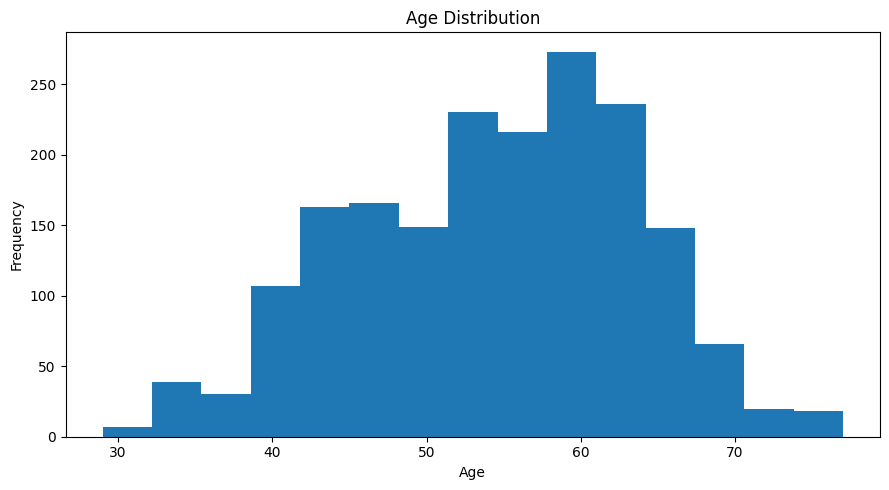

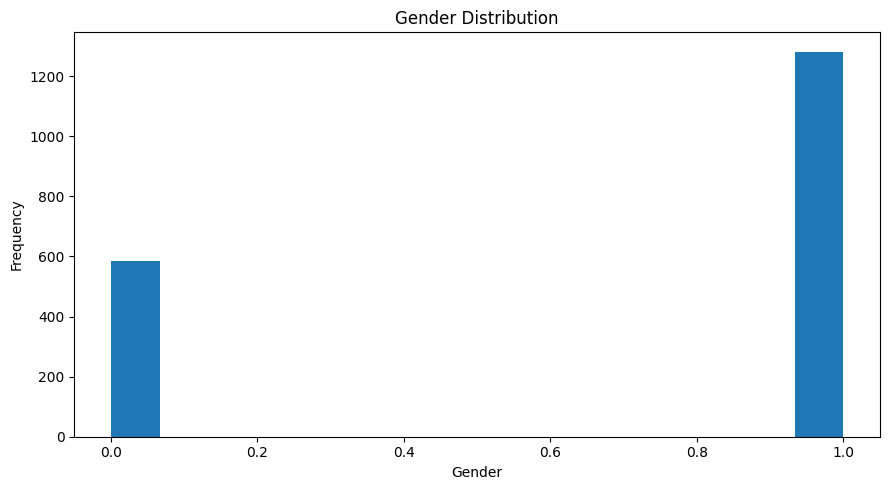

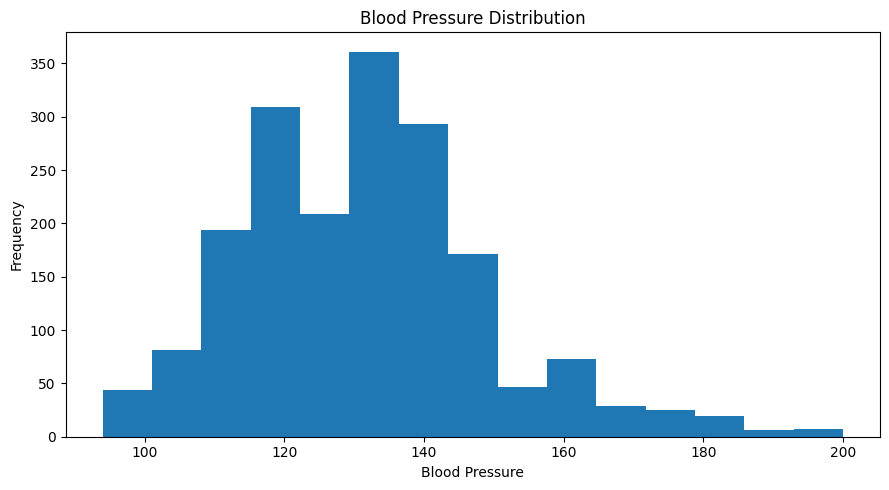

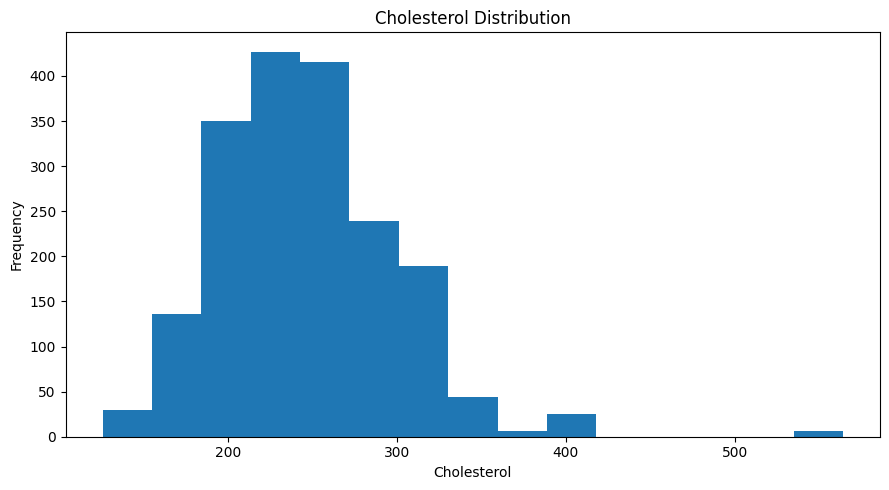

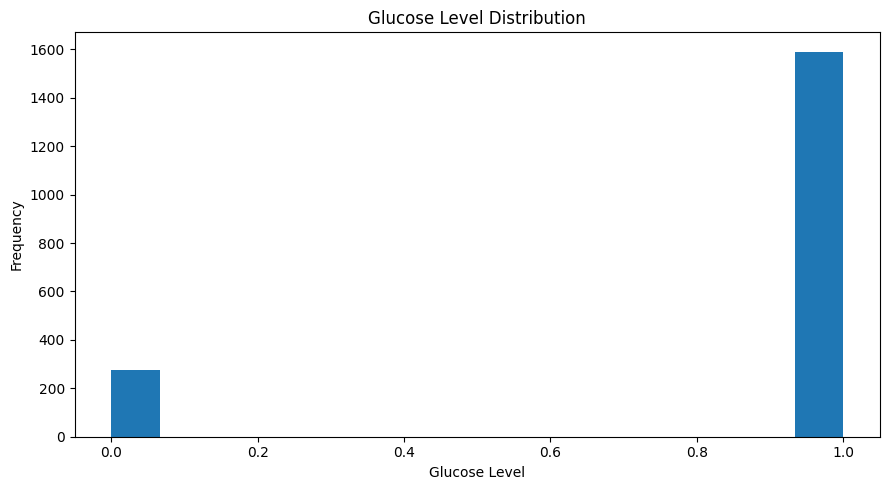

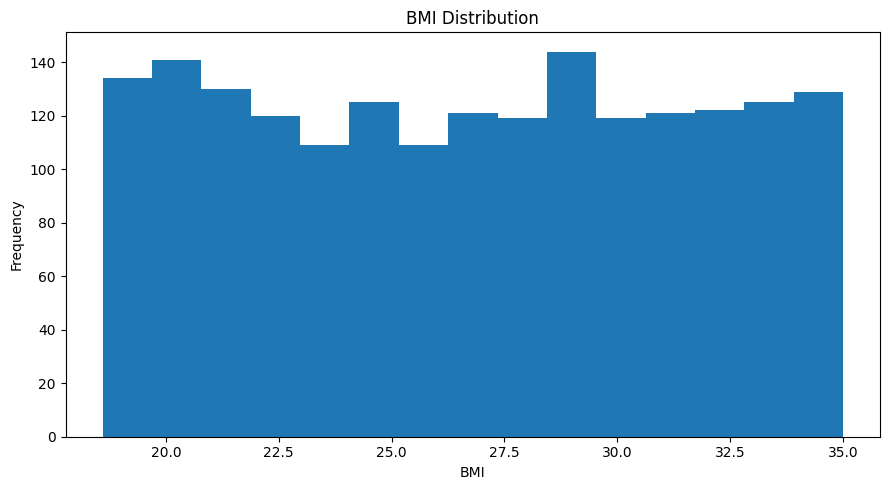

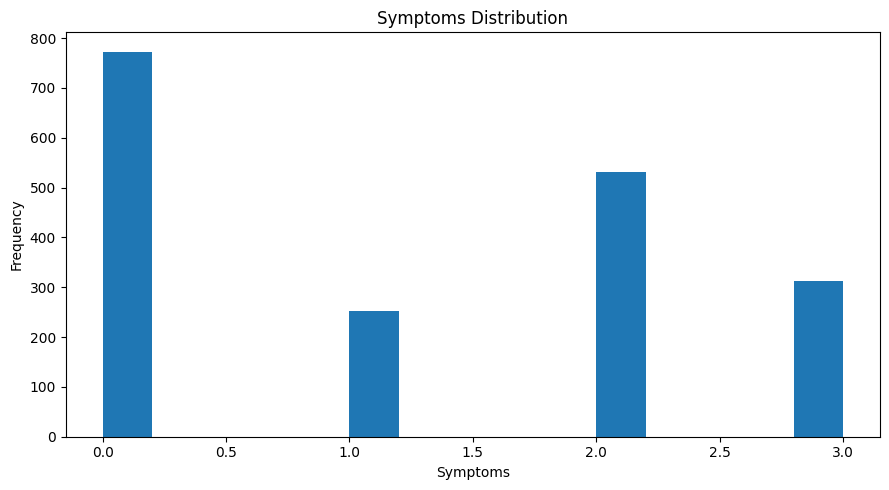

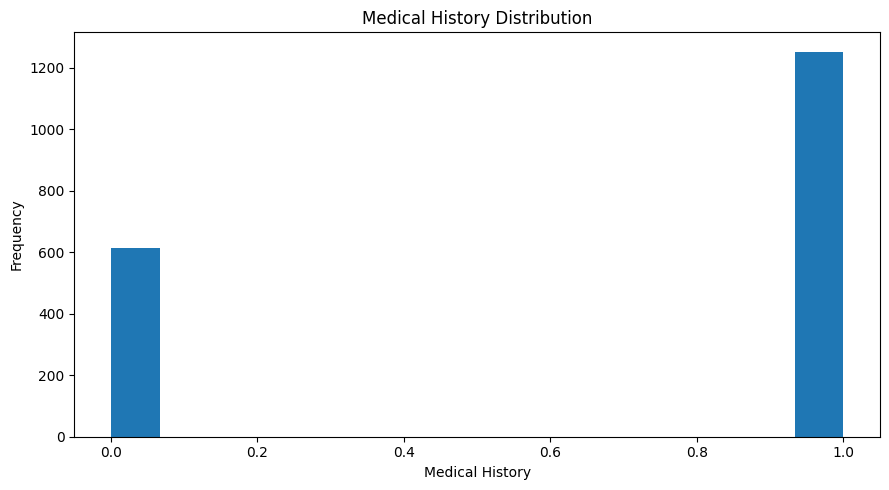

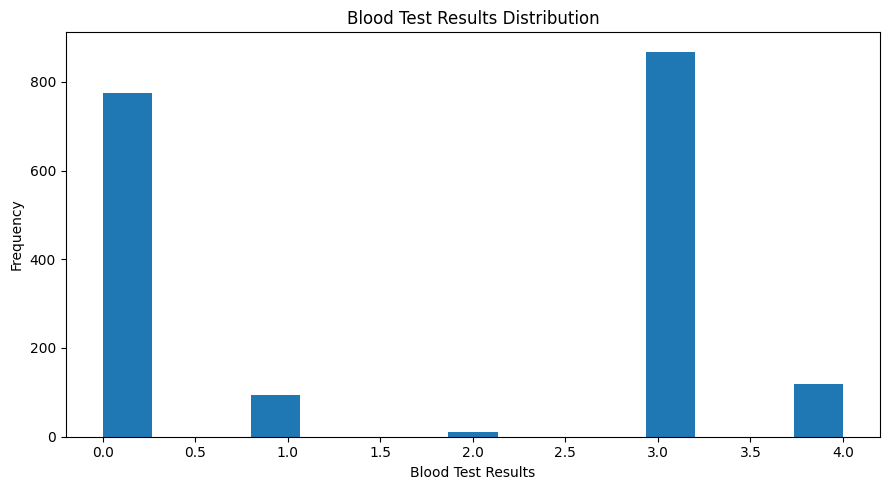

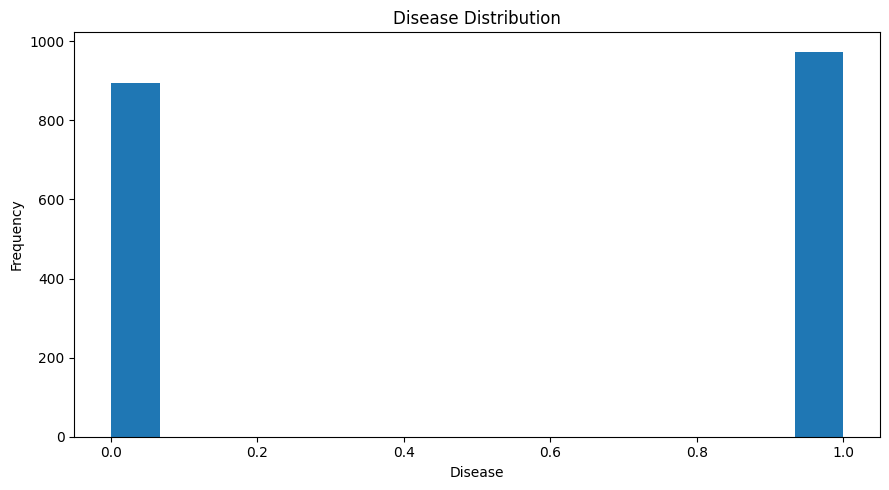

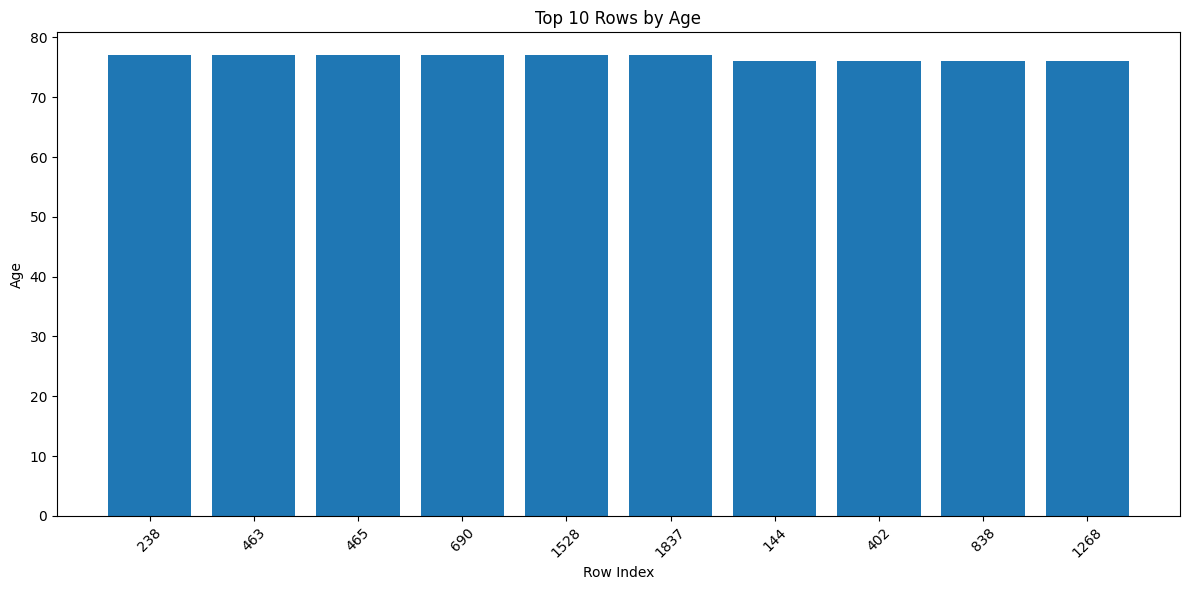

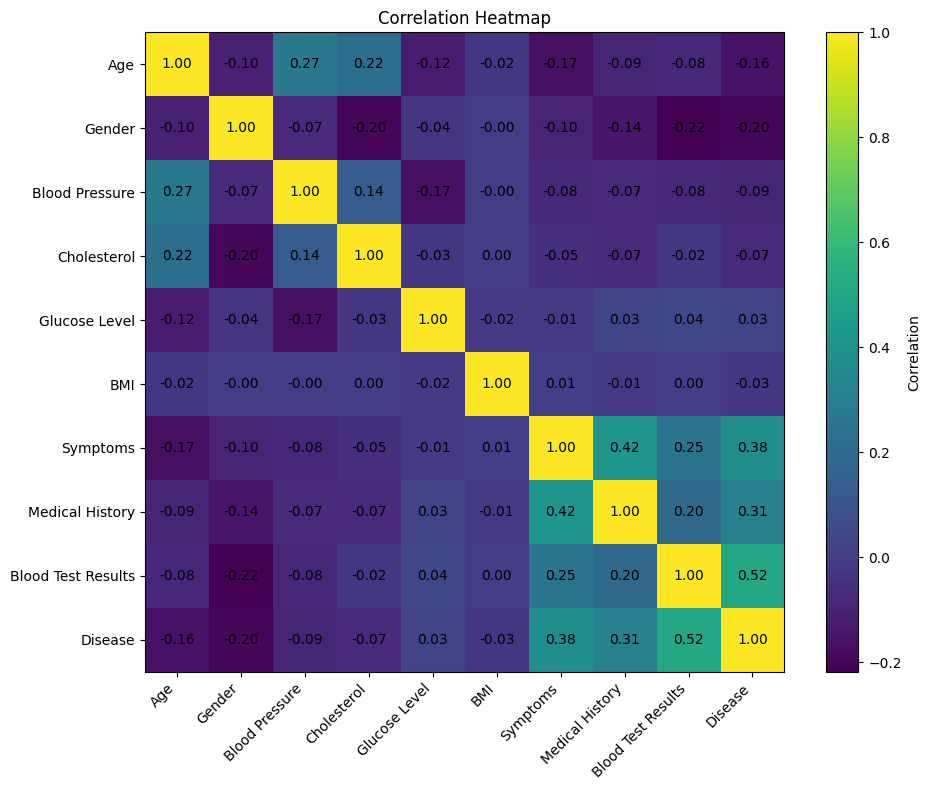

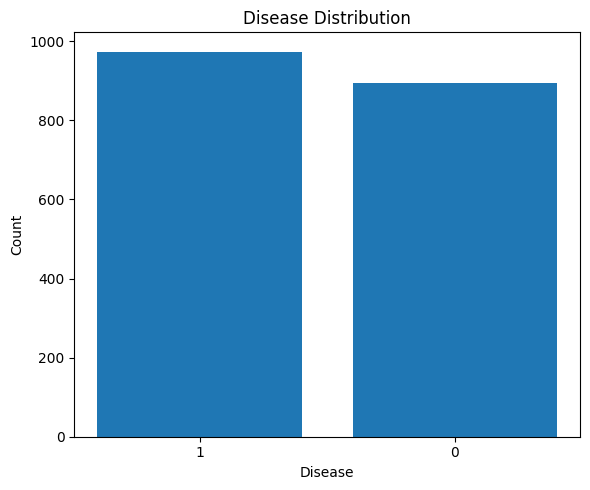

In [87]:
plot_credit_numeric_eda_separate(df)

# DATA PREPROCESSING

In [41]:
# MEAN OF NUMERICAL COLUMNS
print("\n==============================")
print("MEAN OF NUMERICAL COLUMNS")
print("==============================")

mean_values = df.mean(numeric_only=True)
print(mean_values)


MEAN OF NUMERICAL COLUMNS
Age                54.344754
Blood Pressure    131.522484
Cholesterol       246.792827
BMI                26.741488
dtype: float64


In [42]:
# MODE OF ALL COLUMNS
print("\n==============================")
print("MODE OF COLUMNS")
print("==============================")

mode_values = df.mode().iloc[0]
print(mode_values)


MODE OF COLUMNS
Age                                  58
Gender                             Male
Blood Pressure                      120
Cholesterol                         234
Glucose Level                    Normal
BMI                                21.4
Symptoms                     Chest Pain
Medical History        No Major History
Blood Test Results    Reversible Defect
Disease                             Yes
Name: 0, dtype: object


# Label encoder

In [44]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])


In [45]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose Level,BMI,Symptoms,Medical History,Blood Test Results,Disease
0,63,1,145,233,0,24.7,1,1,1,1
1,37,1,130,250,1,34.2,2,1,3,1
2,41,0,130,204,1,30.6,3,1,3,1
3,56,1,120,236,1,28.4,3,1,3,1
4,57,0,120,354,1,21.1,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
1883,60,1,140,207,1,31.1,0,0,0,0
1884,46,1,140,311,1,21.1,0,0,0,0
1885,59,1,134,204,1,26.1,1,1,3,0
1886,54,1,154,232,1,18.7,3,1,3,0


In [46]:
print("\nEncoded Dataset:")
print(df.head())


Encoded Dataset:
   Age  Gender  Blood Pressure  Cholesterol  Glucose Level   BMI  Symptoms  \
0   63       1             145          233              0  24.7         1   
1   37       1             130          250              1  34.2         2   
2   41       0             130          204              1  30.6         3   
3   56       1             120          236              1  28.4         3   
4   57       0             120          354              1  21.1         0   

   Medical History  Blood Test Results  Disease  
0                1                   1        1  
1                1                   3        1  
2                1                   3        1  
3                1                   3        1  
4                0                   3        1  


# StandardScaler

In [47]:
numeric_df = df.select_dtypes(include=np.number)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(
    scaled_data,
   columns=numeric_df.columns
)
scaled_df.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose Level,BMI,Symptoms,Medical History,Blood Test Results,Disease
0,0.951154,0.676090,0.769253,-0.266661,-2.396598,-0.422100,-0.177699,0.700587,-0.464438,0.958052
1,-1.906073,0.676090,-0.086899,0.062005,0.417258,1.542127,0.691259,0.700587,0.841160,0.958052
2,-1.466500,-1.479092,-0.086899,-0.827328,0.417258,0.797789,1.560217,0.700587,0.841160,0.958052
3,0.181901,0.676090,-0.657666,-0.208661,0.417258,0.342915,1.560217,0.700587,0.841160,0.958052
4,0.291794,-1.479092,-0.657666,2.072671,0.417258,-1.166438,-1.046657,-1.427375,0.841160,0.958052


In [48]:
print("\nScaled Dataset:")
print(scaled_df.head())


Scaled Dataset:
        Age    Gender  Blood Pressure  Cholesterol  Glucose Level       BMI  \
0  0.951154  0.676090        0.769253    -0.266661      -2.396598 -0.422100   
1 -1.906073  0.676090       -0.086899     0.062005       0.417258  1.542127   
2 -1.466500 -1.479092       -0.086899    -0.827328       0.417258  0.797789   
3  0.181901  0.676090       -0.657666    -0.208661       0.417258  0.342915   
4  0.291794 -1.479092       -0.657666     2.072671       0.417258 -1.166438   

   Symptoms  Medical History  Blood Test Results   Disease  
0 -0.177699         0.700587           -0.464438  0.958052  
1  0.691259         0.700587            0.841160  0.958052  
2  1.560217         0.700587            0.841160  0.958052  
3  1.560217         0.700587            0.841160  0.958052  
4 -1.046657        -1.427375            0.841160  0.958052  


In [49]:
summary = pd.DataFrame({
    "Mean": mean_values
})

summary.to_csv("mean_values.csv")

print("\nMean values saved successfully!")


Mean values saved successfully!


# Feature Selection

In [50]:
# Last column as target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nFEATURE COLUMNS")
print(X.columns)

print("\nTARGET COLUMN")
print(y.name)


FEATURE COLUMNS
Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose Level',
       'BMI', 'Symptoms', 'Medical History', 'Blood Test Results'],
      dtype='object')

TARGET COLUMN
Disease


In [51]:
# ==========================================
# FEATURE SELECTION USING CHI-SQUARE
# ==========================================

print("\n===================================")
print("FEATURE SELECTION - CHI SQUARE")
print("===================================")

chi_selector = SelectKBest(score_func=chi2, k='all')

X_new = chi_selector.fit_transform(X, y)

chi_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_selector.scores_
})

chi_scores = chi_scores.sort_values(
    by='Chi2 Score',
    ascending=False
)

print(chi_scores)


FEATURE SELECTION - CHI SQUARE
              Feature  Chi2 Score
8  Blood Test Results  682.773251
6            Symptoms  302.057685
3         Cholesterol   99.967313
0                 Age   73.528301
7     Medical History   60.614922
2      Blood Pressure   37.928246
1              Gender   22.293963
5                 BMI    1.096465
4       Glucose Level    0.274081


In [52]:
# ==========================================
# FEATURE SELECTION USING MUTUAL INFO
# ==========================================

print("\n===================================")
print("FEATURE SELECTION - MUTUAL INFO")
print("===================================")

mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='Mutual Information Score',
    ascending=False
)

print(mi_df)


FEATURE SELECTION - MUTUAL INFO
              Feature  Mutual Information Score
3         Cholesterol                  0.146528
8  Blood Test Results                  0.142964
6            Symptoms                  0.083875
7     Medical History                  0.040941
2      Blood Pressure                  0.031038
0                 Age                  0.023701
1              Gender                  0.007892
4       Glucose Level                  0.007414
5                 BMI                  0.005785


In [62]:
# ==========================================
# FEATURE IMPORTANCE USING RANDOM FOREST
# ==========================================

print("\n===================================")
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("===================================")

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# ==========================================
# TOP IMPORTANT FEATURES
# ==========================================

print("\n===================================")
print("TOP IMPORTANT FEATURES")
print("===================================")

top_features = feature_importance.head(5)

print(top_features)


FEATURE IMPORTANCE - RANDOM FOREST
              Feature  Importance
8  Blood Test Results    0.239112
3         Cholesterol    0.151458
0                 Age    0.148137
6            Symptoms    0.138097
2      Blood Pressure    0.127070
5                 BMI    0.074089
7     Medical History    0.065579
1              Gender    0.035619
4       Glucose Level    0.020839

TOP IMPORTANT FEATURES
              Feature  Importance
8  Blood Test Results    0.239112
3         Cholesterol    0.151458
0                 Age    0.148137
6            Symptoms    0.138097
2      Blood Pressure    0.127070


# Train Test Split

In [55]:
# DEFINE FEATURES AND TARGET
X = df.drop("Disease", axis=1)   # Input features
y = df["Disease"]                # Target column


In [56]:

# TRAIN TEST SPLIT
# 80% Training Data
# 20% Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [57]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose Level,BMI,Symptoms,Medical History,Blood Test Results,Disease
0,63,1,145,233,0,24.7,1,1,1,1
1,37,1,130,250,1,34.2,2,1,3,1
2,41,0,130,204,1,30.6,3,1,3,1
3,56,1,120,236,1,28.4,3,1,3,1
4,57,0,120,354,1,21.1,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
1883,60,1,140,207,1,31.1,0,0,0,0
1884,46,1,140,311,1,21.1,0,0,0,0
1885,59,1,134,204,1,26.1,1,1,3,0
1886,54,1,154,232,1,18.7,3,1,3,0


In [58]:
# ==========================================
# DISPLAY SHAPES
# ==========================================
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

# ==========================================
# DISPLAY SAMPLE DATA
# ==========================================
print("\nTraining Data Sample")
print(X_train.head())

print("\nTesting Data Sample")
print(X_test.head())

X_train shape : (1494, 9)
X_test shape  : (374, 9)
y_train shape : (1494,)
y_test shape  : (374,)

Training Data Sample
      Age  Gender  Blood Pressure  Cholesterol  Glucose Level   BMI  Symptoms  \
1147   60       1             140          293              1  29.4         0   
244    56       1             132          184              1  18.8         0   
1170   41       1             110          235              1  28.7         3   
1259   49       0             130          269              1  28.1         0   
724    42       0             102          265              1  28.0         0   

      Medical History  Blood Test Results  
1147                1                   0  
244                 0                   1  
1170                1                   3  
1259                1                   3  
724                 1                   3  

Testing Data Sample
      Age  Gender  Blood Pressure  Cholesterol  Glucose Level   BMI  Symptoms  \
1716   56       1          

# Model Training

In [59]:
# ==========================================
# CREATE MODELS
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(probability=True),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
      
    )
}

# Model Evaluation


MODEL : SVM
Accuracy : 0.5641711229946524
Precision: 0.571700826325799
Recall   : 0.5641711229946524
F1-Score : 0.542104129962849
ROC-AUC  : 0.6445741758241759


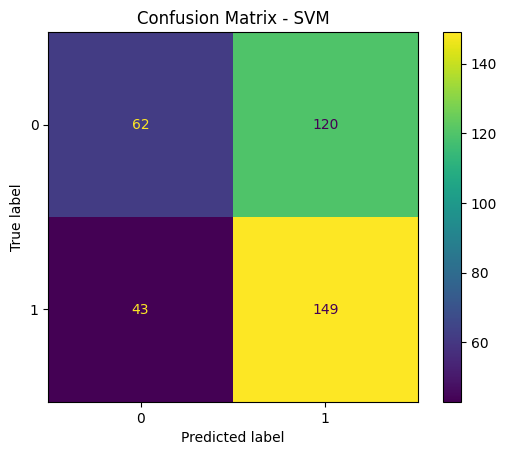


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.34      0.43       182
           1       0.55      0.78      0.65       192

    accuracy                           0.56       374
   macro avg       0.57      0.56      0.54       374
weighted avg       0.57      0.56      0.54       374



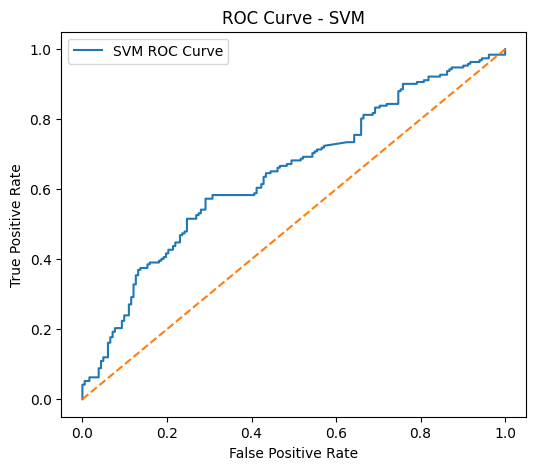


MODEL : Logistic Regression
Accuracy : 0.7887700534759359
Precision: 0.7887480862907773
Recall   : 0.7887700534759359
F1-Score : 0.7887534277422465
ROC-AUC  : 0.8435210622710623


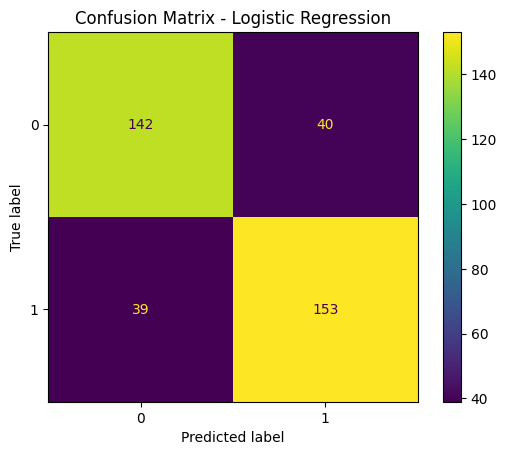


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       182
           1       0.79      0.80      0.79       192

    accuracy                           0.79       374
   macro avg       0.79      0.79      0.79       374
weighted avg       0.79      0.79      0.79       374



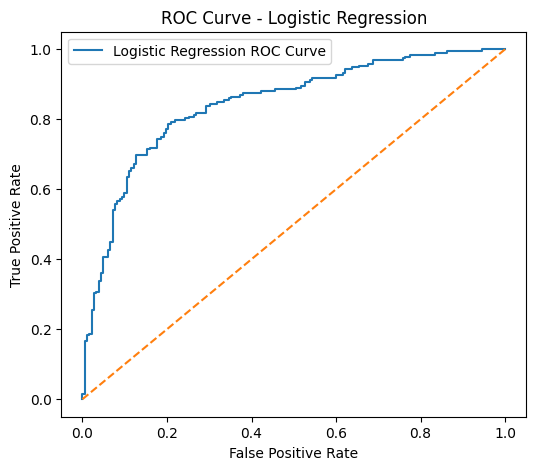


MODEL : Random Forest
Accuracy : 0.9732620320855615
Precision: 0.9737279209204344
Recall   : 0.9732620320855615
F1-Score : 0.9732436475781858
ROC-AUC  : 0.9909283424908425


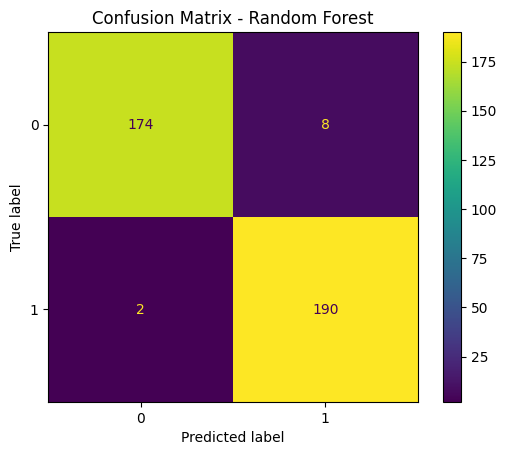


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       182
           1       0.96      0.99      0.97       192

    accuracy                           0.97       374
   macro avg       0.97      0.97      0.97       374
weighted avg       0.97      0.97      0.97       374



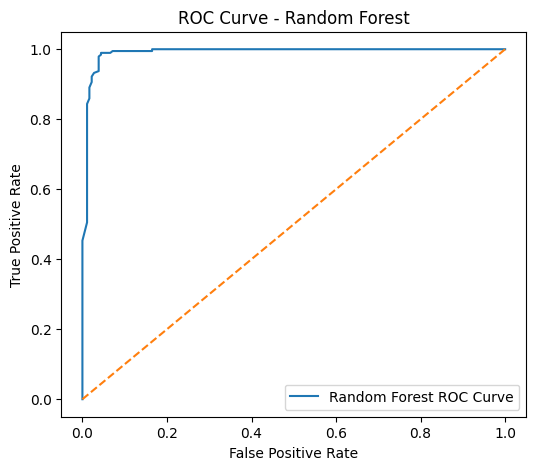


MODEL : XGBoost
Accuracy : 0.9598930481283422
Precision: 0.9609124172959198
Recall   : 0.9598930481283422
F1-Score : 0.959843890053798
ROC-AUC  : 0.9818853021978022


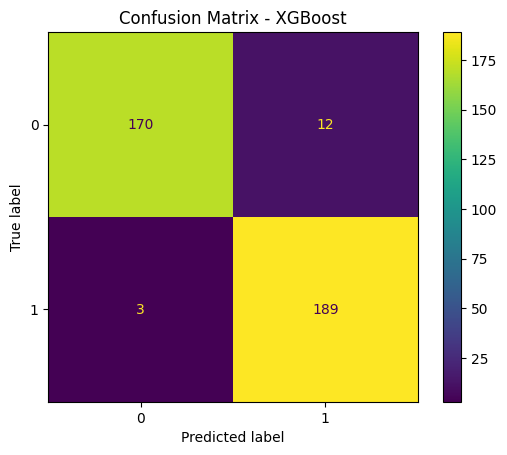


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       182
           1       0.94      0.98      0.96       192

    accuracy                           0.96       374
   macro avg       0.96      0.96      0.96       374
weighted avg       0.96      0.96      0.96       374



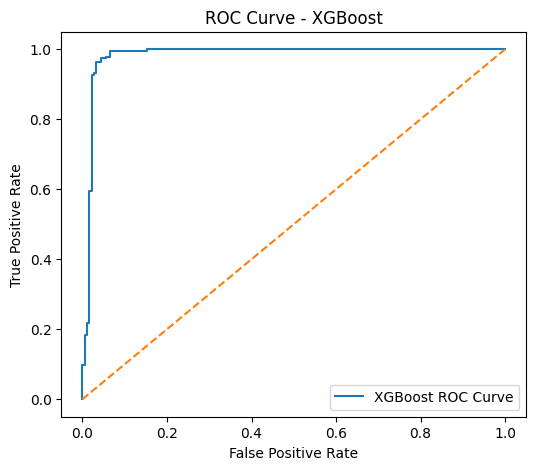

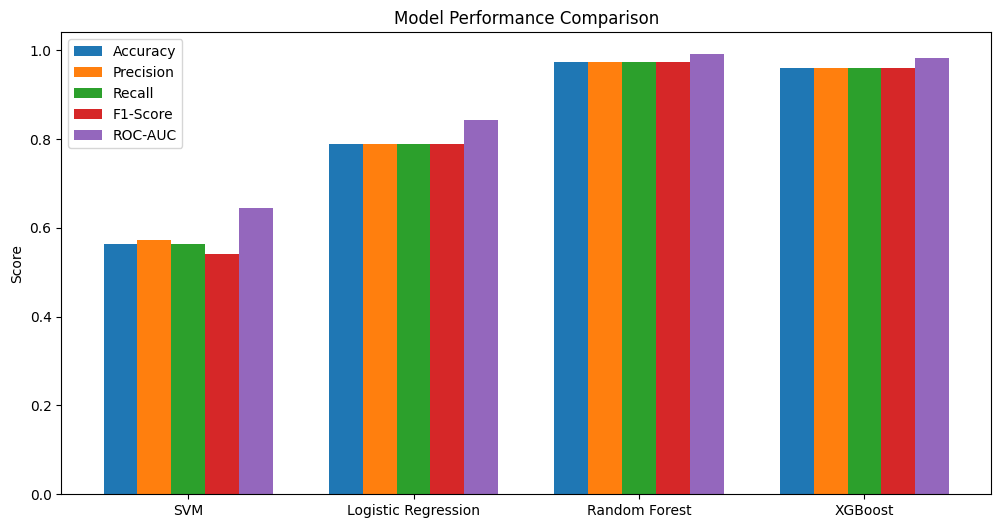

In [75]:
# ==========================================
# MODELS
# ==========================================
models = {
    "SVM": SVC(probability=True),
   "Logistic Regression": LogisticRegression(max_iter=5000, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# ==========================================
# STORE METRICS
# ==========================================
model_names = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
roc_auc_list = []

# ==========================================
# TRAIN & EVALUATE MODELS
# ==========================================
for name, model in models.items():

    print("\n===================================")
    print("MODEL :", name)
    print("===================================")

    # TRAIN MODEL
    model.fit(X_train, y_train)

    # PREDICTIONS
    predictions = model.predict(X_test)

    # PROBABILITY
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = predictions

    # METRICS
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # PRINT RESULTS
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
    print("ROC-AUC  :", roc_auc)

    # STORE VALUES
    model_names.append(name)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    roc_auc_list.append(roc_auc)


    # ==========================================
    # CONFUSION MATRIX GRAPH
    # ==========================================
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ==========================================
    # Classification Report
    # ==========================================

    print("\nClassification Report:")

    print(classification_report(y_test, predictions))
    

    # ==========================================
    # ROC CURVE GRAPH
    # ==========================================
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{name} ROC Curve")
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

# ==========================================
# COMPARISON GRAPH
# ==========================================

x = np.arange(len(model_names))
width = 0.15

plt.figure(figsize=(12,6))

plt.bar(x - 0.30, accuracy_list, width, label='Accuracy')
plt.bar(x - 0.15, precision_list, width, label='Precision')
plt.bar(x, recall_list, width, label='Recall')
plt.bar(x + 0.15, f1_list, width, label='F1-Score')
plt.bar(x + 0.30, roc_auc_list, width, label='ROC-AUC')

plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()


# Evaluation Metrics


Evaluation Metrics
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0                  SVM  0.564171   0.553903  0.776042  0.646421  0.644617
1  Logistic Regression  0.788770   0.792746  0.796875  0.794805  0.843521
2        Random Forest  0.967914   0.954545  0.984375  0.969231  0.991358
3              XGBoost  0.959893   0.940299  0.984375  0.961832  0.981885


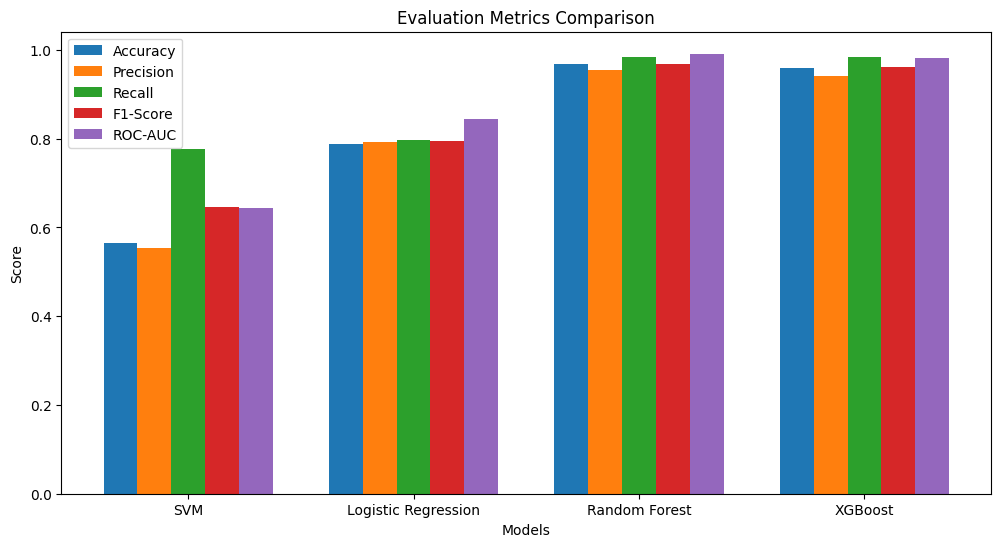

In [76]:
# ==========================================
# CREATE RESULT DATAFRAME
# ==========================================
results = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores,
    'ROC-AUC': roc_aucs
})

print("\nEvaluation Metrics")
print(results)
# ==========================================
# GRAPH - EVALUATION METRICS
# ==========================================

x = np.arange(len(model_names))
width = 0.15

plt.figure(figsize=(12,6))

plt.bar(x - 0.30, accuracies, width, label='Accuracy')
plt.bar(x - 0.15, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + 0.15, f1_scores, width, label='F1-Score')
plt.bar(x + 0.30, roc_aucs, width, label='ROC-AUC')

plt.xticks(x, model_names)
plt.ylabel("Score")
plt.xlabel("Models")
plt.title("Evaluation Metrics Comparison")
plt.legend()

plt.show()